# Submission 2 &ndash; Intermediate Submission

## Instructions

- Fill out the *Basic Information* and the *Results* sections.
- Make sure that this `.ipynb` file displays correctly in the GitHub file preview, including any visual output.
- If you find that any output does not display correctly, include a static screenshot as an image. For interactive outputs, add a link to a short screencast located in your repository.
- Push all required files before the deadline.

---
## Basic Information

**Team Name:** powerpuff-girls

**Team Members:**
- Saba Zia Naserani
- Elemdin Zukic
- Egzona Gashi
- TODO

**Dataset Description:**  
(max. 75 words; this serves just as a reminder)

< This dataset contains a comprehensive list of all movies and TV shows available on Netflix up to 2021. Sourced from Kaggle, it includes 8,807 titles and 12 attributes, such as title, director, cast, country, release year, rating, duration, and genre. It provides a robust foundation for analyzing content distribution, temporal trends, and platform-specific characteristics, such as the ratio of movies to TV shows and the evolution of content over the years. >

---

## Code

Here you may place any code that is not an immediate part of your submission. Only the content of the *Results* sections will be graded for this submission.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/netflix_titles.csv')

# Clean date_added column
df_clean = df.dropna(subset=['date_added']).copy()
df_clean['date_added'] = df_clean['date_added'].str.strip()
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], format='mixed')
df_clean['year_added'] = df_clean['date_added'].dt.year

print("Data loaded successfully")
print(f"Total rows: {len(df)}")
print(f"Rows with valid dates: {len(df_clean)}")

Data loaded successfully
Total rows: 8807
Rows with valid dates: 8797


---
## Results &ndash; Simple Hypotheses/Tasks

### A.1

Restate your hypothesis/task below.

**Hypthesis/Task A.1:** Netflix's catalog contains significantly more Movies than TV Shows.

Place your visualizations below (max. 2). Make sure that everyting displays correctly in the GitHub file preview.

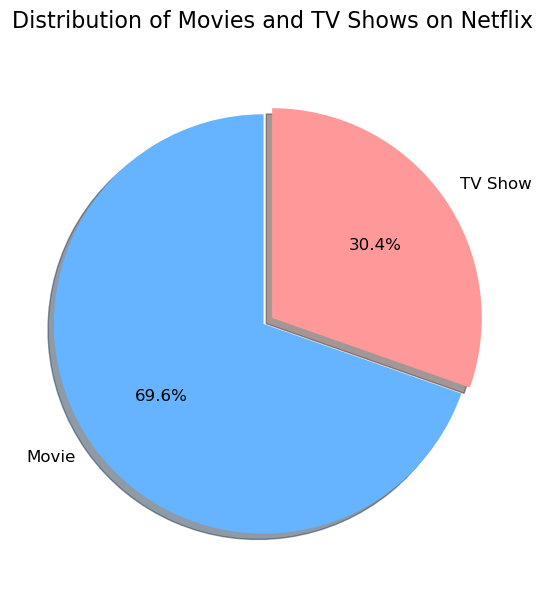

In [11]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(8,6))
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0)
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=explode, shadow=True, textprops={'fontsize':12})
plt.title('Distribution of Movies and TV Shows on Netflix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Describe your visualizations and findings. Be clear which chart(s) you are referring to and relate your findings to the hypothesis/task.
Use no more than 150 words and indicate the word count of your description below.

**Description:** 
The pie chart confirms the hypothesis: Movies make up 69.6% of Netflix's catalog, while TV Shows account for 30.4%. 
This roughly 70/30 split shows Netflix prioritizes movies over series in raw title count. 
The "exploded" Movie slice visually emphasizes the majority. 
This insight is important because any further analysis of Netflix content should treat movies and TV shows separately, as their volumes differ significantly.

**Word count**: 66

### A.2

Restate your hypothesis/task below.

**Hypthesis/Task A.2:** The number of new titles added to Netflix has increased substantially over the years, especially from the mid‑2010s.

Place your visualizations below (max. 2). Make sure that everyting displays correctly in the GitHub file preview.

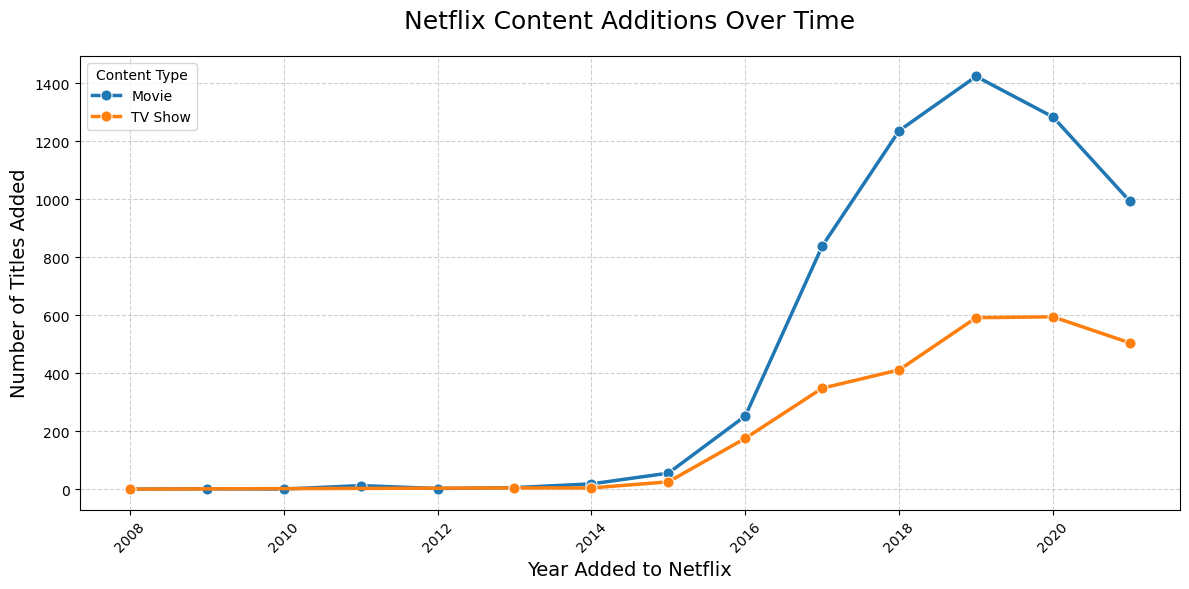

In [13]:
yearly_counts = df_clean.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_counts, x='year_added', y='count', hue='type',
             marker='o', linewidth=2.5, markersize=8)
plt.title('Netflix Content Additions Over Time', fontsize=18, pad=20)
plt.xlabel('Year Added to Netflix', fontsize=14)
plt.ylabel('Number of Titles Added', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

Describe your visualizations and findings. Be clear which chart(s) you are referring to and relate your findings to the hypothesis/task. Use no more than 150 words and indicate the word count of your description below.

**Description:** The line chart strongly supports the hypothesis. Before 2014, almost no titles were added (zero from 2008–2012). Growth begins in 2014 (~10 titles), accelerates to ~300 in 2016, then explodes to ~1,400 in 2018 before dropping to ~1,000 in 2020. The sharp rise from 2014–2018 reflects Netflix's global expansion and original content investment. The 2020 dip may be due to pandemic production delays or data collection cut‑off. Overall, the "Netflix Effect" is clearly visible.

**Word count**: 98